Purpose: Look at GO enrichment results for HybridExpress-TS gene intersections of each physiotype of *Y. gloriosa*.<br>
Author: Anna Pardo<br>
Date initiated: May 11, 2026

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from venn import venn

In [2]:
# load results
res = pd.read_csv("./GOenrichres_HybExp_TS_intgenes.txt",sep="\t",header="infer")
res.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,1.389017e-16,GO:0006091,1.224592e-13,CAM_TS_UP,BP,generation of precursor metabolites and ...,594,47,11.15,1.400000e-16,generation of precursor metabolites and energy
1,3.990088e-05,GO:0006139,5.862935e-03,CAM_TS_UP,BP,nucleobase-containing compound metabolic...,7000,173,131.41,4.000000e-05,nucleobase-containing compound metabolic process
2,3.625731e-04,GO:0006950,3.706128e-02,CAM_TS_UP,BP,response to stress,4418,113,82.94,3.600000e-04,response to stress
3,1.078826e-18,GO:0007623,1.521792e-15,CAM_TS_UP,BP,circadian rhythm,246,33,4.62,1.100000e-18,circadian rhythm
4,3.719619e-17,GO:0008150,3.747782e-14,CAM_TS_UP,BP,biological_process,22867,521,429.27,3.700000e-17,biological_process


In [3]:
res.groupby("regset").count().reset_index()[["regset","GO.term"]].sort_values(by="GO.term",ascending=False)

,regset,GO.term
4,C3+CAM_TS_UP,97
1,C3+CAM_TS_DOWN,91
7,CAM_TS_ELD_P1,87
6,CAM_TS_DOWN,84
9,CAM_TS_UP,77
2,C3+CAM_TS_ELD_P1,76
3,C3+CAM_TS_ELD_P2,68
8,CAM_TS_ELD_P2,44
0,C3+CAM_TS_ADD,29
5,CAM_TS_ADD,20


In [22]:
# make Venn diagrams for GO term overlaps of each class (UP, DOWN, etc) across physiotypes
def class_plot_venn(c,save=True,d="./"):
    if not os.path.exists(d):
        os.makedirs(d)
        
    regsets = [i for i in res["regset"].unique() if c in i]
    if c=="CAM":
        regsets = [i for i in regsets if i.startswith("CAM")]

    # assemble dictionary for Venn diagram construction
    venndict = {}
    for i in regsets:
        df = res[res["regset"]==i]
        venndict[i] = set(list(df["GO.term"]))
    
    venn(venndict)
    plt.title(c+" HybridExpress-TS GO term overlaps",fontsize=20)
    
    if save:
        fbase = c+"_TSHE_GOterms_venn"
        plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

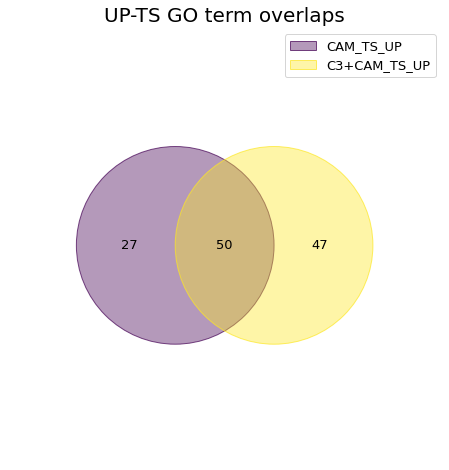

In [7]:
class_plot_venn("UP",True,"./TS_HybExp_GO_venns/")

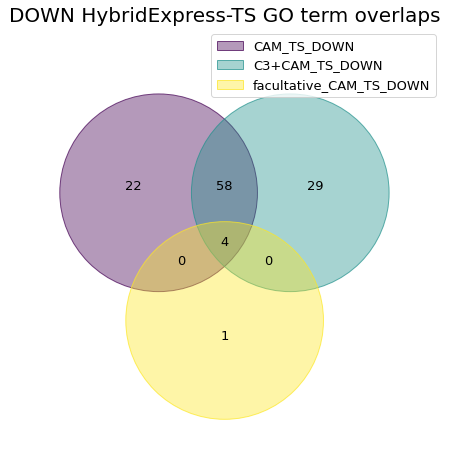

In [24]:
class_plot_venn("DOWN",True,"./TS_HybExp_GO_venns/")

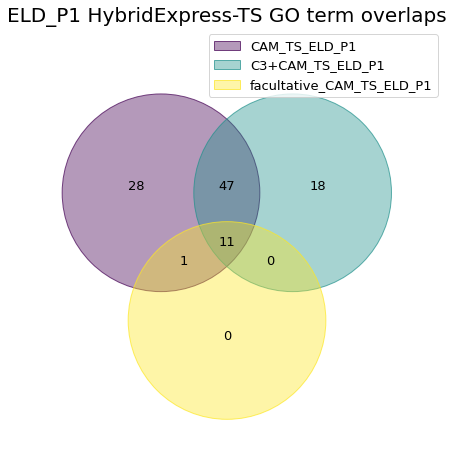

In [25]:
class_plot_venn("ELD_P1",True,"./TS_HybExp_GO_venns/")

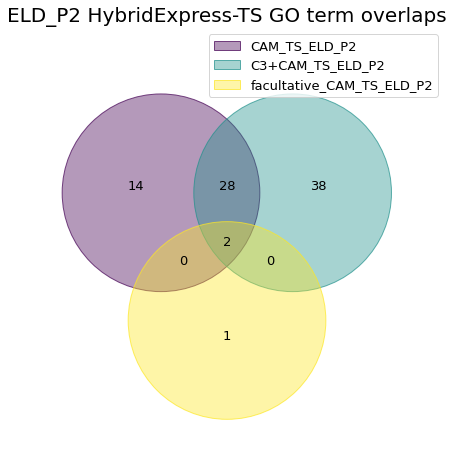

In [26]:
class_plot_venn("ELD_P2",True,"./TS_HybExp_GO_venns/")

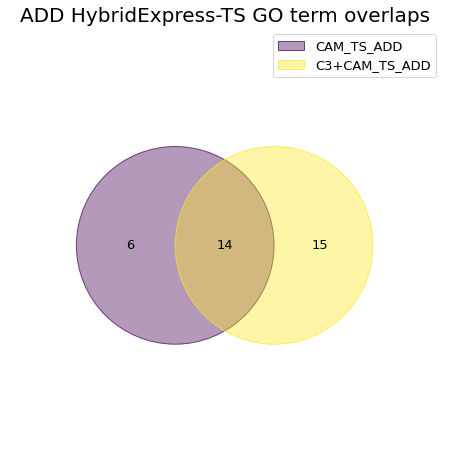

In [27]:
class_plot_venn("ADD",True,"./TS_HybExp_GO_venns/")

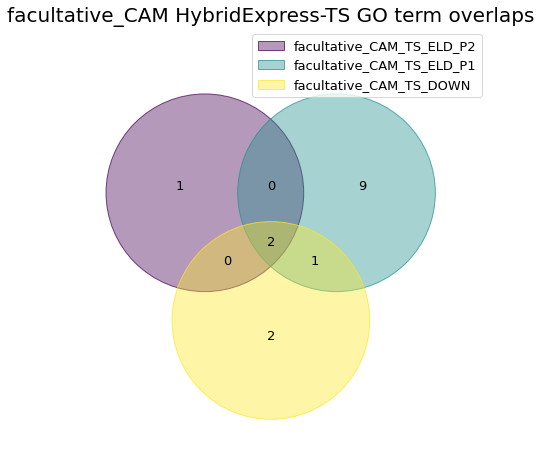

In [28]:
# now make overlaps among classes for each physiology
class_plot_venn("facultative_CAM",True,"./TS_HybExp_GO_venns/")

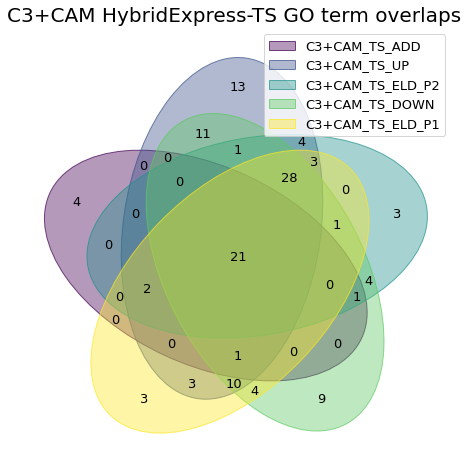

In [29]:
class_plot_venn("C3+CAM",True,"./TS_HybExp_GO_venns/")

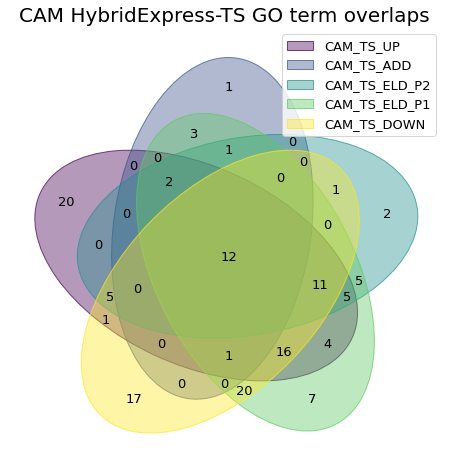

In [30]:
class_plot_venn("CAM",True,"./TS_HybExp_GO_venns/")

In [31]:
# set up for Revigo: output list of GO terms to input there
with open("./TS_HybExp_GO_venns/HybExp_TS_allGOterms_forRevigo.txt","w+") as outfile:
    for i in res["GO.term"].unique():
        outfile.write(i+"\n")

In [33]:
# load Revigo results
revigo = pd.read_csv("./Revigo_BP_OnScreenTable_GOterms_HybExpTSint.csv",sep=",",header="infer",usecols=["TermID","Name"])
revigo.head()

,TermID,Name
0,GO:0000302,response to reactive oxygen species
1,GO:0000373,Group II intron splicing
2,GO:0000377,"RNA splicing, via transesterification reaction..."
3,GO:0003006,developmental process involved in reproduction
4,GO:0006091,generation of precursor metabolites and energy


In [34]:
revigo.rename(columns={"TermID":"GO.term"},inplace=True)

In [35]:
# subset res to only revigo terms
revres = res.merge(revigo)
revres.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr,Name
0,1.389017e-16,GO:0006091,1.224592e-13,CAM_TS_UP,BP,generation of precursor metabolites and ...,594,47,11.15,1.400000e-16,generation of precursor metabolites and energy,generation of precursor metabolites and energy
1,4.862804e-06,GO:0006091,1.633207e-03,CAM_TS_ELD_P2,BP,generation of precursor metabolites and ...,594,28,10.72,4.900000e-06,generation of precursor metabolites and energy,generation of precursor metabolites and energy
2,1.244264e-05,GO:0006091,2.193949e-03,CAM_TS_DOWN,BP,generation of precursor metabolites and ...,594,22,7.69,1.200000e-05,generation of precursor metabolites and energy,generation of precursor metabolites and energy
3,9.926826e-05,GO:0006091,1.346421e-02,C3+CAM_TS_ELD_P2,BP,generation of precursor metabolites and ...,594,21,8.22,9.900000e-05,generation of precursor metabolites and energy,generation of precursor metabolites and energy
4,3.990088e-05,GO:0006139,5.862935e-03,CAM_TS_UP,BP,nucleobase-containing compound metabolic...,7000,173,131.41,4.000000e-05,nucleobase-containing compound metabolic process,nucleobase-containing compound metabolic process


In [36]:
set(revres["Descr"]).difference(set(revres["Name"]))

{"2'-deoxyribonucleoside metabolic process",
 'obsolete negative regulation of amide metabolic process',
 'obsolete regulation of amide metabolic process'}

In [37]:
set(revres["Name"]).difference(set(revres["Descr"]))

{'deoxyribonucleoside metabolic process',
 'negative regulation of amide metabolic process',
 'regulation of amide metabolic process'}

In [47]:
# use the Name column from hereon out
## re-make all these nice Venn diagrams I just made

def class_plot_venn(c,save=True,d="./"):
    if not os.path.exists(d):
        os.makedirs(d)
        
    regsets = [i for i in revres["regset"].unique() if c in i]
    if c=="CAM":
        regsets = [i for i in regsets if i.startswith("CAM")]
        
    print(len(revres[revres["regset"].isin(regsets)]["GO.term"].unique()))

    # assemble dictionary for Venn diagram construction
    venndict = {}
    for i in regsets:
        df = revres[revres["regset"]==i]
        venndict[i] = set(list(df["GO.term"]))
    
    venn(venndict)
    plt.title(c+" HybridExpress-TS GO term overlaps",fontsize=20)
    
    if save:
        fbase = c+"_TSHE_GOterms_venn_revigo"
        plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

30


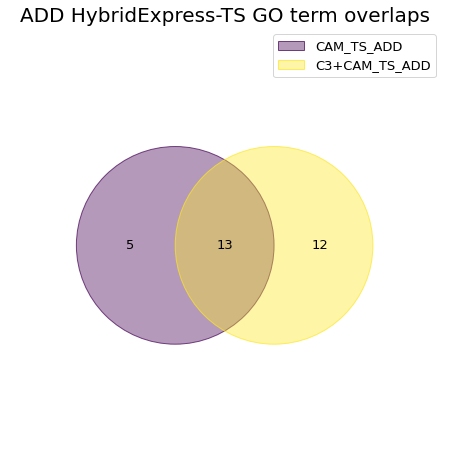

In [48]:
class_plot_venn("ADD",True,"./TS_HybExp_GO_venns/")

78


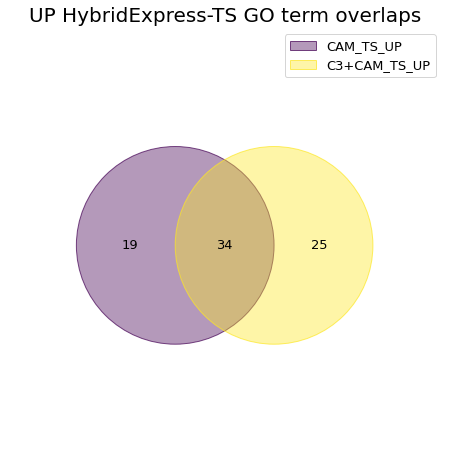

In [49]:
class_plot_venn("UP",True,"./TS_HybExp_GO_venns/")

71


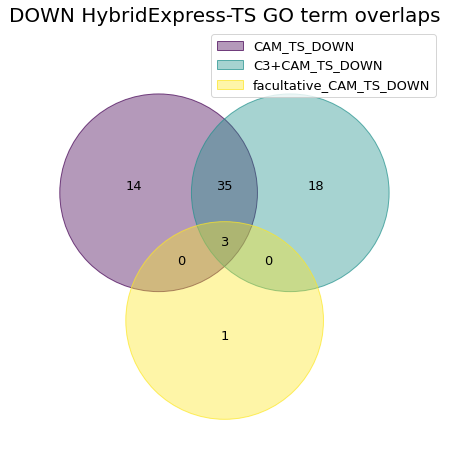

In [50]:
class_plot_venn("DOWN",True,"./TS_HybExp_GO_venns/")

67


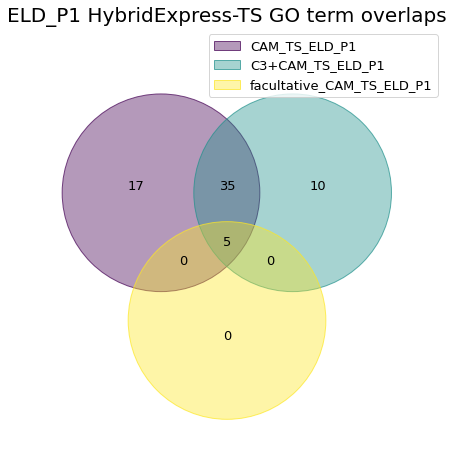

In [51]:
class_plot_venn("ELD_P1",True,"./TS_HybExp_GO_venns/")

55


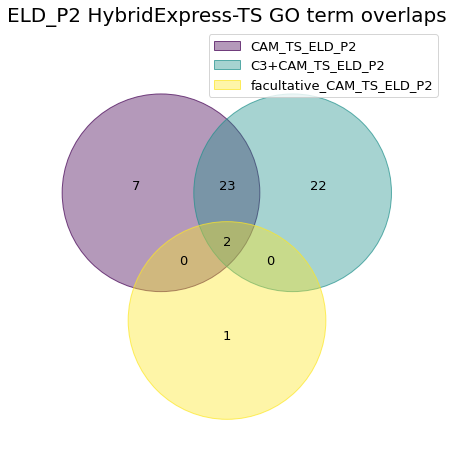

In [52]:
class_plot_venn("ELD_P2",True,"./TS_HybExp_GO_venns/")

89


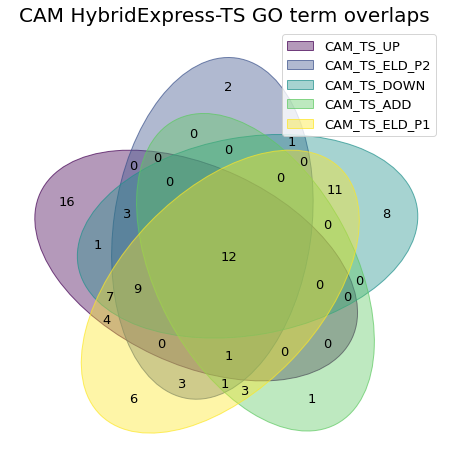

In [53]:
class_plot_venn("CAM",True,"./TS_HybExp_GO_venns/")

80


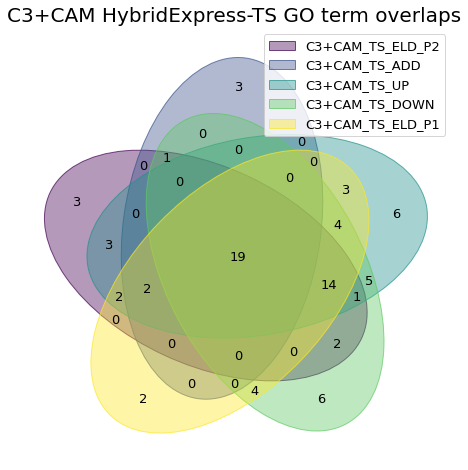

In [54]:
class_plot_venn("C3+CAM",True,"./TS_HybExp_GO_venns/")

8


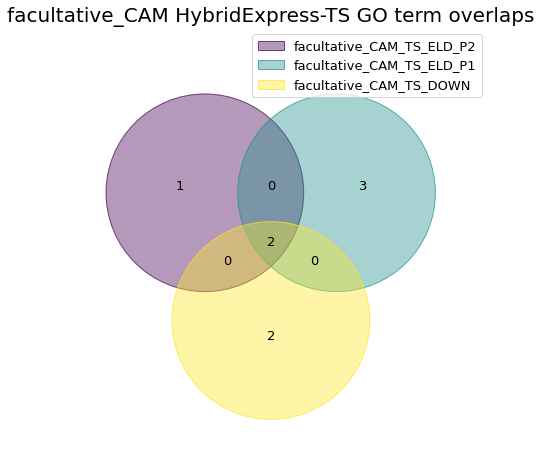

In [55]:
class_plot_venn("facultative_CAM",True,"./TS_HybExp_GO_venns/")

In [56]:
len(revres["GO.term"].unique())

109

In [57]:
# make an overall heatmap (109 GO terms should be...reasonably interpretable)
plot = revres.pivot(index="Name",columns="regset",values="p.adj")
plot.head()

regset,C3+CAM_TS_ADD,C3+CAM_TS_DOWN,C3+CAM_TS_ELD_P1,C3+CAM_TS_ELD_P2,C3+CAM_TS_UP,CAM_TS_ADD,CAM_TS_DOWN,CAM_TS_ELD_P1,CAM_TS_ELD_P2,CAM_TS_UP,facultative_CAM_TS_DOWN,facultative_CAM_TS_ELD_P1,facultative_CAM_TS_ELD_P2
Name,,,,,,,,,,,,,
DNA-templated transcription,NaN,0.005067,2.821856e-03,7.159992e-03,1.711329e-02,NaN,0.003653,3.385656e-02,NaN,NaN,NaN,NaN,NaN
Group II intron splicing,NaN,NaN,1.662076e-02,2.873844e-03,1.485538e-02,NaN,0.016447,NaN,NaN,NaN,NaN,NaN,NaN
RNA metabolic process,0.000009,0.000008,2.586534e-09,5.175613e-08,2.147584e-07,0.000543,0.000138,1.038081e-07,0.000899,0.001118,NaN,NaN,NaN
RNA modification,0.000059,0.037303,1.692228e-04,2.830238e-04,4.706702e-04,0.000125,NaN,1.533751e-05,0.000584,NaN,NaN,NaN,NaN
RNA splicing,NaN,NaN,8.123710e-03,NaN,8.444978e-03,NaN,0.001087,1.785696e-02,NaN,NaN,NaN,NaN,NaN


In [60]:
len(plot.columns)

13

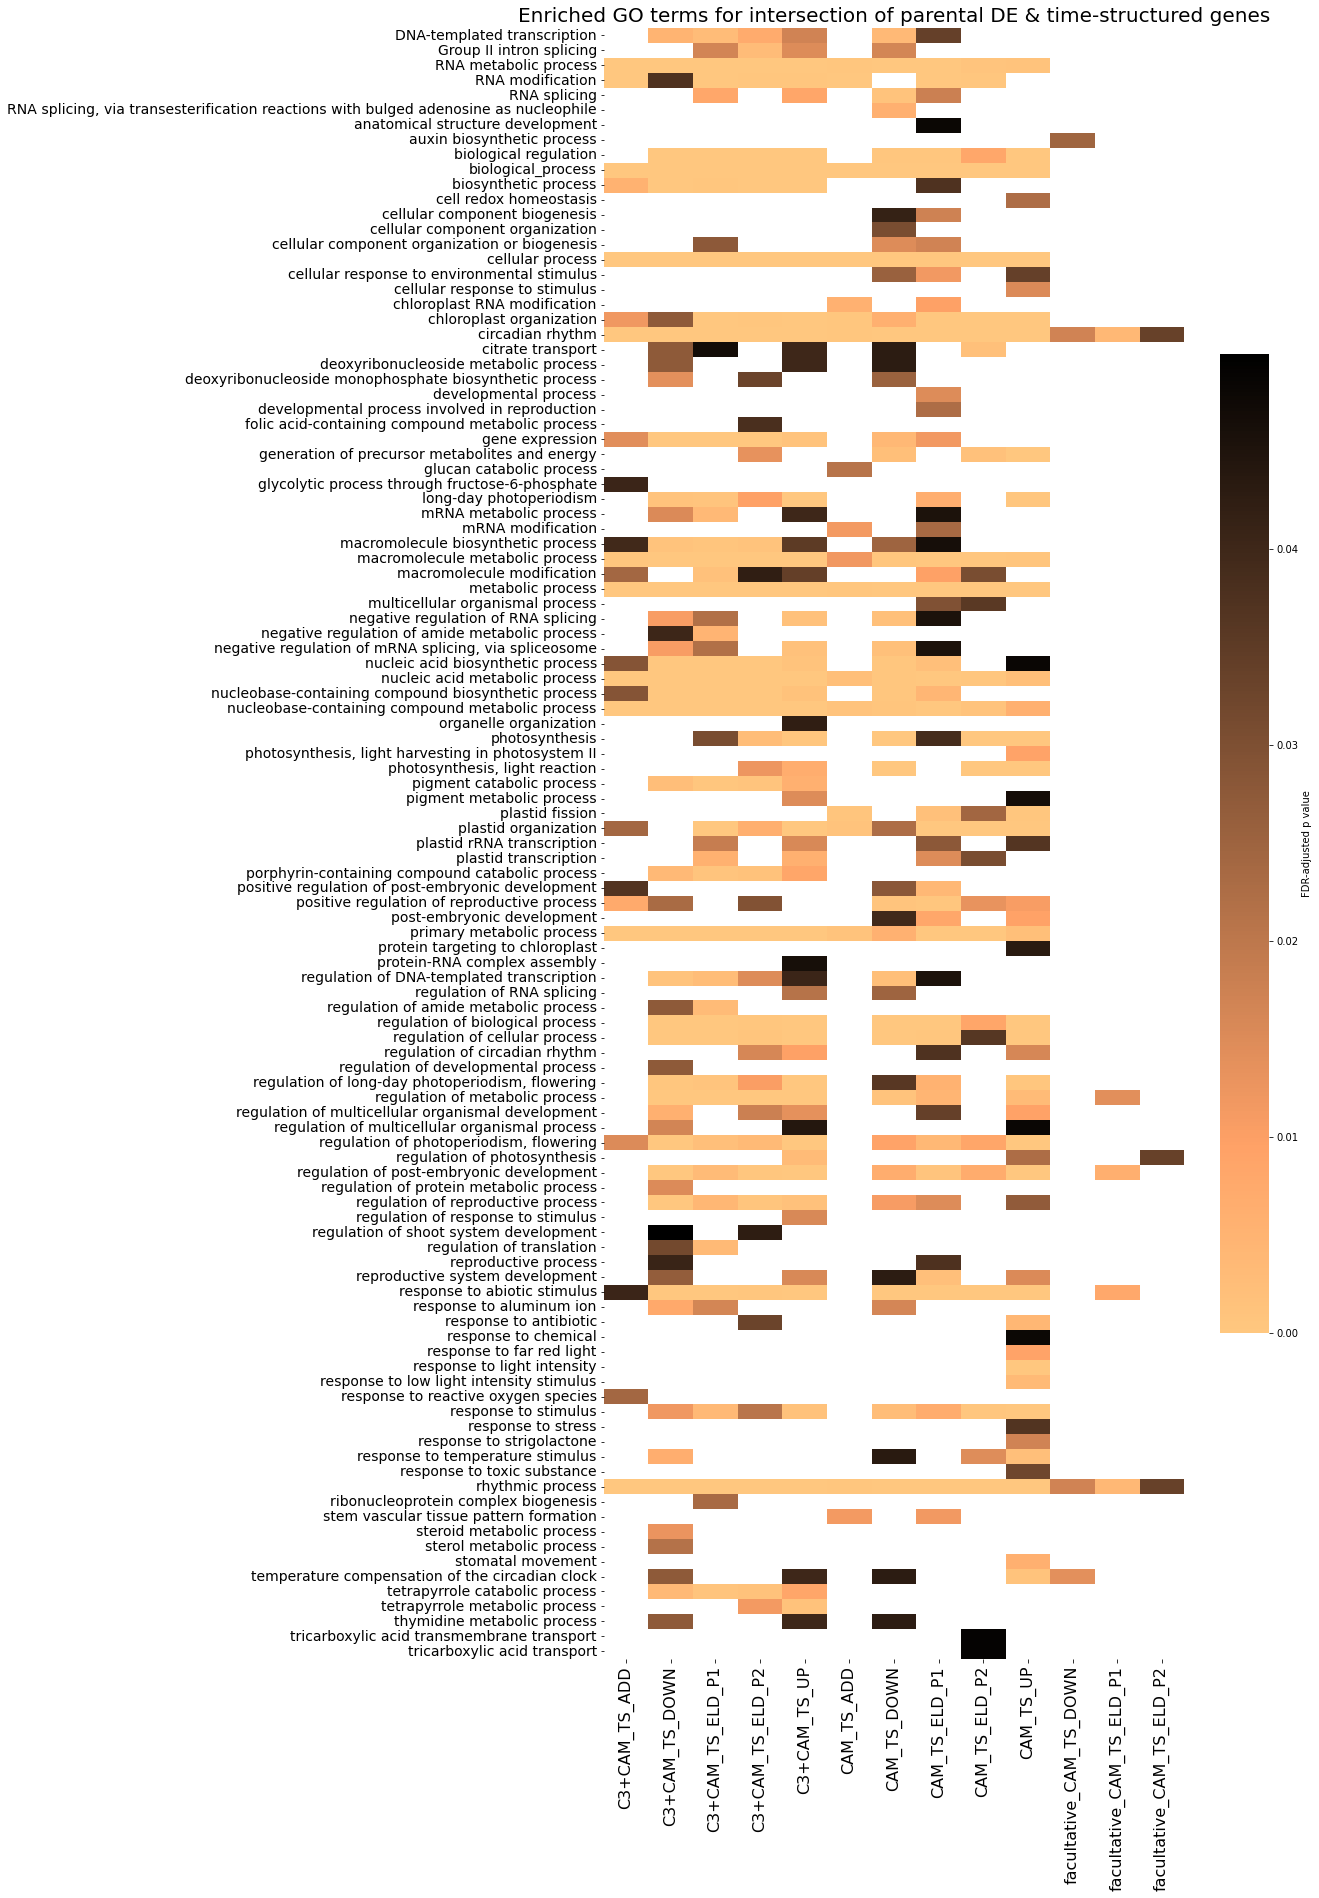

In [68]:
plt.subplots(figsize=(13,30))
sns.heatmap(plot,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(fontsize=16)
plt.xlabel("")
plt.title("Enriched GO terms for intersection of parental DE & time-structured genes",fontsize=20)

plt.savefig("./TS_HybExp_GO_venns/GO_enrichment_heatmap_HybExpTS.png",dpi=300,bbox_inches="tight")
plt.savefig("./TS_HybExp_GO_venns/GO_enrichment_heatmap_HybExpTS.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./TS_HybExp_GO_venns/GO_enrichment_heatmap_HybExpTS.svg",dpi=300,bbox_inches="tight")